# 01 — PDF Extraction & Cleaning

This notebook extracts proportional-candidate rows from the Election Commission PDF and saves a clean CSV for analysis.

Variables of interest:
- **लिङ्ग** (Gender)
- **समावेशी समूह** (Inclusive Group)
- **नागरिकता जारी जिल्ला** (Citizenship-issuing district)

> The PDF mixes Nepali + English. During extraction, some Nepali diacritics can be lost; we normalize the main categories robustly.

In [13]:
# Paths
import sys
from pathlib import Path

PROJECT_DIR = Path("..").resolve()
# Add project root to sys.path so `src` package can be imported
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

PDF_PATH = PROJECT_DIR / "data" / "raw" / "PreliminaryCandidateListPR_2082_10_06.pdf"
OUT_CSV = PROJECT_DIR / "data" / "processed" / "candidates.csv"

FIG_DIR = PROJECT_DIR / "outputs" / "figures"
TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

PDF_PATH

PosixPath('/Users/bikki/Downloads/nepal_pr_candidate_analysis/data/raw/PreliminaryCandidateListPR_2082_10_06.pdf')

In [14]:
import pandas as pd
from src.utils import extract_candidates_from_pdf
from src.canonical import standardize_party_district, CANONICAL_PARTIES, CANONICAL_DISTRICTS

df = extract_candidates_from_pdf(str(PDF_PATH))
df = standardize_party_district(df)

# Save parsing mismatches for manual review
party_unknown = (df.loc[df['party'] == 'UNKNOWN_PARTY', ['party_raw']]
                 .value_counts()
                 .rename('count')
                 .reset_index()
                 .sort_values('count', ascending=False))
district_unknown = (df.loc[df['नागरिकता जारी जिल्ला'] == 'UNKNOWN_DISTRICT', ['district_raw']]
                    .value_counts()
                    .rename('count')
                    .reset_index()
                    .sort_values('count', ascending=False))
party_unknown.to_csv(TABLE_DIR / 'party_unknown_values.csv', index=False, encoding='utf-8')
district_unknown.to_csv(TABLE_DIR / 'district_unknown_values.csv', index=False, encoding='utf-8')

df.head()


,party,serial,name,voter_no,लिङ्ग,समावेशी समूह,नागरिकता जारी जिल्ला,party_raw,district_raw
0,नेपाल मजदुर किसान पार्टी,1,हमालयवरलाल मूल,5336130,पुरुष,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
1,नेपाल मजदुर किसान पार्टी,2,हुछे मैया सुवाल,5360114,महिला,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
2,नेपाल मजदुर किसान पार्टी,3,नमा कुमार गु ङ,14660162,महिला,आदिवासी जनजाति,दैलेख,नेपाल मजदुर िकसान पाट,दैलेख
3,नेपाल मजदुर किसान पार्टी,4,राजे साद हाडा,5336657,पुरुष,आदिवासी जनजाति,भक्तपुर,नेपाल मजदुर िकसान पाट,भतपुर
4,नेपाल मजदुर किसान पार्टी,5,काशी नारायण डगं ोल,5435191,पुरुष,आदिवासी जनजाति,काठमाडौं,नेपाल मजदुर िकसान पाट,काठमाडौ


In [15]:
# Quick sanity checks
print('Rows:', len(df))
print('Unique parties:', df['party'].nunique())
print('Unique districts:', df['नागरिकता जारी जिल्ला'].nunique())
print('Unknown parties:', int((df['party'] == 'UNKNOWN_PARTY').sum()))
print('Unknown districts:', int((df['नागरिकता जारी जिल्ला'] == 'UNKNOWN_DISTRICT').sum()))
print('Gender values:', df['लिङ्ग'].value_counts(dropna=False).to_dict())
print('Inclusive groups:', df['समावेशी समूह'].value_counts(dropna=False).head(10).to_dict())

# Guardrails against drift from the provided canonical lists
party_outside = sorted(set(df['party'].unique()) - set(CANONICAL_PARTIES) - {'UNKNOWN_PARTY'})
district_outside = sorted(set(df['नागरिकता जारी जिल्ला'].unique()) - set(CANONICAL_DISTRICTS) - {'UNKNOWN_DISTRICT'})
print('Outside-party values:', party_outside)
print('Outside-district values:', district_outside)


Rows: 3200
Unique parties: 42
Unique districts: 66
Unknown parties: 896
Unknown districts: 239
Gender values: {'महिला': 1807, 'पुरुष': 1393}
Inclusive groups: {'खस आर्य': 763, 'आदिवासी जनजाति': 749, 'ष': 607, 'मधेशी': 408, 'दलत': 352, 'थारु': 178, 'मुिलम': 130, 'मधशे': 9, 'मिु': 4}
Outside-party values: []
Outside-district values: []


In [16]:

# Save processed CSV
df.to_csv(OUT_CSV, index=False, encoding="utf-8")
OUT_CSV


PosixPath('/Users/bikki/Downloads/nepal_pr_candidate_analysis/data/processed/candidates.csv')

In [17]:
# Export a basic overview table (canonical parties only)
party_counts = (df[df['party'] != 'UNKNOWN_PARTY']
                .groupby('party', as_index=False)
                .size()
                .rename(columns={'size':'candidates'})
                .sort_values('candidates', ascending=False))
party_counts.to_csv(TABLE_DIR / 'party_candidate_counts.csv', index=False, encoding='utf-8')
party_counts.head(20)


,party,candidates
10,नेपाल कम्युनिष्ट पार्टी (एमाले),110
13,नेपाल कम्युनिष्ट पार्टी (संयुक्त),110
33,राष्ट्रिय जात पार्टी,110
36,श्रम संस्कृति पार्टी,110
23,नेपाली कम्युनिष्ट पार्टी,110
21,नेपाल सद्भावना पार्टी,110
35,राष्ट्रिय स्वतन्त्र पार्टी,109
18,नेपाल मजदुर किसान पार्टी,109
6,जनमत पार्टी,109
11,नेपाल कम्युनिष्ट पार्टी (माओवादी),109


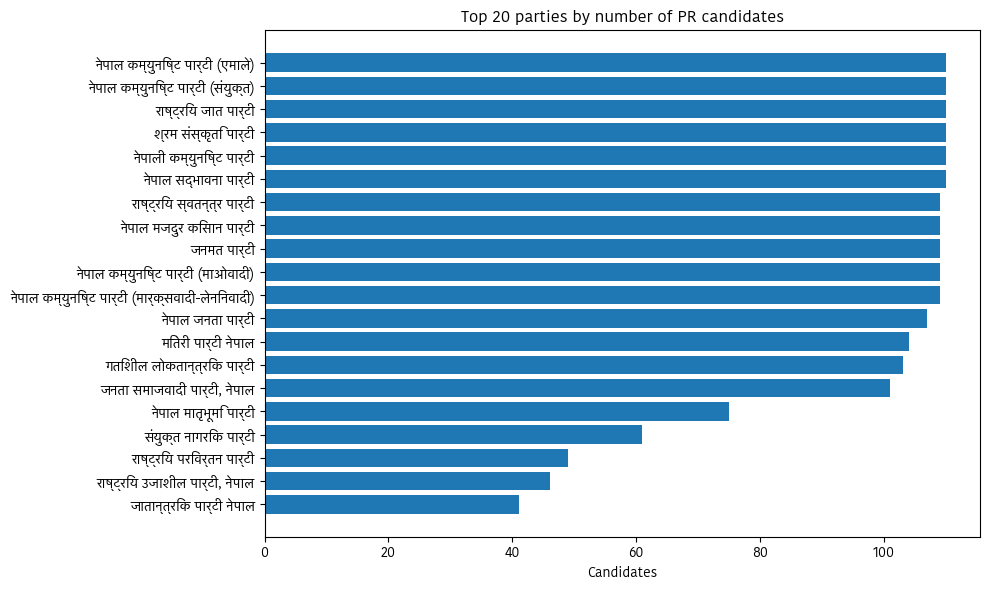

PosixPath('/Users/bikki/Downloads/nepal_pr_candidate_analysis/outputs/figures/top20_parties_by_candidates.png')

In [18]:
# Optional: quick plot of candidate counts per party (top 20)
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Kohinoor Devanagari'

top = party_counts.head(20).copy()
plt.figure(figsize=(10, 6))
plt.barh(top["party"][::-1], top["candidates"][::-1])
plt.xlabel("Candidates")
plt.title("Top 20 parties by number of PR candidates")
plt.tight_layout()
out = FIG_DIR / "top20_parties_by_candidates.png"
plt.savefig(out, dpi=200)
plt.show()
out